# RNA-seq _Escherichia coli_ K12

## Raw data description

**WT**, **Dam-**, **AlkB-** samples for _E.coli_:

In [17]:
!ls ecoli_rnaseq_data/*fastq.bz2

ecoli_rnaseq_data/240219_Alkb_Ecoli_1.fastq.bz2
ecoli_rnaseq_data/240219_Alkb_Ecoli_2.fastq.bz2
ecoli_rnaseq_data/240219_Alkb_Ecoli_3.fastq.bz2
ecoli_rnaseq_data/240219_DAM_Ecoli_1.fastq.bz2
ecoli_rnaseq_data/240219_DAM_Ecoli_2.fastq.bz2
ecoli_rnaseq_data/240219_DAM_Ecoli_3.fastq.bz2
ecoli_rnaseq_data/240219_WT_Ecoli_1.fastq.bz2
ecoli_rnaseq_data/240219_WT_Ecoli_2.fastq.bz2
ecoli_rnaseq_data/240219_WT_Ecoli_3.fastq.bz2
ecoli_rnaseq_data/240311_Alkb_Ecoli_1.fastq.bz2
ecoli_rnaseq_data/240311_Alkb_Ecoli_2.fastq.bz2
ecoli_rnaseq_data/240313_DAM_Ecoli_1.fastq.bz2
ecoli_rnaseq_data/240313_DAM_Ecoli_2.fastq.bz2
ecoli_rnaseq_data/240313_DAM_Ecoli_3.fastq.bz2


## 1. Контроль качества (Quality Control (QC)). rRNA contamination removal

In [13]:
# convert bz2 files to gz
!cd ecoli_rnaseq_data && for f in *.bz2; do bzcat "$f" | gzip -c >"${f%.*}.gz"; done

In [ ]:
!conda install -c bioconda fastqc -y

In [ ]:
!mkdir ecoli_rnaseq_data/fastqc_outputs && \
fastqc ecoli_rnaseq_data/*fastq.gz -o ecoli_rnaseq_data/fastqc_outputs

**Results of QC**. \
Errors in the sections: 
1. 'Per tile sequence quality' - ok cause 'I would not worry too much in this case since you had poor quality only in one tile, while the rest of the flowcell looks good. This should not affect downstream analysis.' (https://www.biostars.org/p/9517843/)
2. 'Per base sequence content' - 'This is totally normal for RNA-sequencing data even after removal of the adapter sequences..' (https://www.biostars.org/p/371979/)
3. 'Per sequence GC content' - may suggest us about rRNA contamination.. 'Only contamination here may be of rRNA depending on how you did your experiments.' (https://www.biostars.org/p/9540513/) _So, we should check our data on it then_.
4. 'Sequence duplication levels' - this is ok cause 'High sequence duplication levels in RNA-seq are normal and expected. Do not remove duplicates. This would underestimate the true expression of highly expressed genes, as it would artificially downscale the counts of these genes.' (https://www.biostars.org/p/307361/)
5. 'Overrepresented sequences' - ok cause 'RNAseq will always contain over-represented sequences, because certain genes will be overly expressed and, thus, will result in over-represented sequences.' (https://www.biostars.org/p/425712/).

**Dealing with rRNA contamination**

In [ ]:
# Install sortmerna to remove rRNA as contamination
!conda install -c bioconda sortmerna==2.0

In [ ]:
# Download the sortmerna package into sortmerna_db folder
!wget -P sortmerna_db https://github.com/biocore/sortmerna/archive/2.1b.zip

# Decompress folder 
!unzip sortmerna_db/2.1b.zip -d sortmerna_db

# Move the database into the correct folder
mv sortmerna_db/sortmerna-2.1b/rRNA_databases/ sortmerna_db/

# Remove unnecessary folders
!rm sortmerna_db/2.1b.zip
!rm -r sortmerna_db/sortmerna-2.1b

# Create folder for the indexed databases
!mkdir sortmerna_db/index

# Indexing of the databases (bacterial only)
!indexdb_rna \
--ref /mnt/storage/lab12/sortmerna_db/rRNA_databases/silva-bac-16s-id90.fasta,/mnt/storage/lab12/sortmerna_db/index/silva-bac-16s-db:/mnt/storage/lab12/sortmerna_db/rRNA_databases/silva-bac-23s-id98.fasta,/mnt/storage/lab12/sortmerna_db/index/silva-bac-23s-db

In [ ]:
# Save variable of rRNA databases
# Save the location of all the databases into one folder
sortmernaREF=/mnt/storage/lab12/sortmerna_db/rRNA_databases/silva-bac-16s-id90.fasta,/mnt/storage/lab12/sortmerna_db/index/silva-bac-16s-db:/mnt/storage/lab12/sortmerna_db/rRNA_databases/silva-bac-23s-id98.fasta,/mnt/storage/lab12/sortmerna_db/index/silva-bac-23s-db

# Create folder for results
!mkdir ecoli_rnaseq_data/sortmerna_results
!mkdir ecoli_rnaseq_data/sortmerna_results/aligned
!mkdir ecoli_rnaseq_data/sortmerna_results/filtered

In [ ]:
# Run SortMeRNA (manually)
# 1 - 240219_Alkb_Ecoli_1
# p.s. input files should be unzipped
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240219_Alkb_Ecoli_1.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240219_Alkb_Ecoli_1_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240219_Alkb_Ecoli_1_filtered.fq \
--fastx --log -a 8 -v

# --fastx Output aligned reads into FASTA/FASTQ file
# -v Produce verbose output when building the index
# -a 8 Number of threads
# aligned - sequences with rRNA contamination
# filtered - sequences without any rRNA contamination

Total reads passing E-value threshold (rRNA contaminated) = 65.21% \
Total reads failing E-value threshold (non contaminated with rRNA) = 34.79% (5,125,331 reads).

In [ ]:
# 2 - 240219_Alkb_Ecoli_2
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240219_Alkb_Ecoli_2.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240219_Alkb_Ecoli_2_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240219_Alkb_Ecoli_2_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 78.34% \
Total reads failing E-value threshold (non contaminated with rRNA) = 21.66% (3,532,698 reads).

In [ ]:
# 3 - 240219_Alkb_Ecoli_3
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240219_Alkb_Ecoli_3.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240219_Alkb_Ecoli_3_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240219_Alkb_Ecoli_3_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 0.75% \
Total reads failing E-value threshold (non contaminated with rRNA) = 99.25% (10,330,406 reads).

In [ ]:
# 4 - 240219_DAM_Ecoli_1
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240219_DAM_Ecoli_1.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240219_DAM_Ecoli_1_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240219_DAM_Ecoli_1_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 14.69% \
Total reads failing E-value threshold (non contaminated with rRNA) = 85.31% (10,314,685 reads).

In [ ]:
# 5 - 240219_DAM_Ecoli_2
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240219_DAM_Ecoli_2.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240219_DAM_Ecoli_2_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240219_DAM_Ecoli_2_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 13.53% \
Total reads failing E-value threshold (non contaminated with rRNA) = 86.47% (10,662,059 reads).

In [ ]:
# 6 - 240219_DAM_Ecoli_3
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240219_DAM_Ecoli_3.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240219_DAM_Ecoli_3_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240219_DAM_Ecoli_3_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 27.73% \
Total reads failing E-value threshold (non contaminated with rRNA) = 72.27% (9,696,163 reads).

In [ ]:
# 7 - 240219_WT_Ecoli_1
!sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240219_WT_Ecoli_1.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240219_WT_Ecoli_1_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240219_WT_Ecoli_1_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 7.32% \
Total reads failing E-value threshold (non contaminated with rRNA) = 92.68% (10,532,871 reads).

In [ ]:
# 8 - 240219_WT_Ecoli_2
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240219_WT_Ecoli_2.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240219_WT_Ecoli_2_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240219_WT_Ecoli_2_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 2.79% \
Total reads failing E-value threshold (non contaminated with rRNA) = 97.21% (10,356,036 reads).

In [ ]:
# 9 - 240219_WT_Ecoli_3
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240219_WT_Ecoli_3.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240219_WT_Ecoli_3_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240219_WT_Ecoli_3_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 1.85% \
Total reads failing E-value threshold (non contaminated with rRNA) = 98.15% (9,609,866 reads).

In [ ]:
# 10 - 240311_Alkb_Ecoli_1
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240311_Alkb_Ecoli_1.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240311_Alkb_Ecoli_1_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240311_Alkb_Ecoli_1_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 0.73% \
Total reads failing E-value threshold (non contaminated with rRNA) = 99.27% (12,176,631 reads).

In [ ]:
# 11 - 240311_Alkb_Ecoli_2
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240311_Alkb_Ecoli_2.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240311_Alkb_Ecoli_2_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240311_Alkb_Ecoli_2_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 0.70% \
Total reads failing E-value threshold (non contaminated with rRNA) = 99.30% (12,180,939 reads).

In [ ]:
# 12 - 240313_DAM_Ecoli_1
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240313_DAM_Ecoli_1.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240313_DAM_Ecoli_1_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240313_DAM_Ecoli_1_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 14.72% \
Total reads failing E-value threshold (non contaminated with rRNA) = 85.28% (6,964,230 reads).

In [ ]:
# 13 - 240313_DAM_Ecoli_2
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240313_DAM_Ecoli_2.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240313_DAM_Ecoli_2_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240313_DAM_Ecoli_2_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 13.54% \
Total reads failing E-value threshold (non contaminated with rRNA) = 86.46% (5,468,956 reads).

In [ ]:
# 14 - 240313_DAM_Ecoli_3
sortmerna \
--ref $sortmernaREF \
--reads ecoli_rnaseq_data/240313_DAM_Ecoli_3.fastq \
--aligned ecoli_rnaseq_data/sortmerna_results/aligned/240313_DAM_Ecoli_3_aligned.fq \
--other ecoli_rnaseq_data/sortmerna_results/filtered/240313_DAM_Ecoli_3_filtered.fq \
--fastx --log -a 8 -v

Total reads passing E-value threshold (rRNA contaminated) = 27.71% \
Total reads failing E-value threshold (non contaminated with rRNA) = 72.29% (5,666,733 reads).

**Merging of reads**

In [1]:
!mkdir ecoli_rnaseq_data/merged_rrna_filtered_reads

In [2]:
# 1 - Alkb_Ecoli_1
!cat \
ecoli_rnaseq_data/sortmerna_results/filtered/240219_Alkb_Ecoli_1_filtered.fq \
ecoli_rnaseq_data/sortmerna_results/filtered/240311_Alkb_Ecoli_1_filtered.fq \
> ecoli_rnaseq_data/merged_rrna_filtered_reads/Alkb_Ecoli_1.fastq

In [3]:
# 2 - Alkb_Ecoli_2
!cat \
ecoli_rnaseq_data/sortmerna_results/filtered/240219_Alkb_Ecoli_2_filtered.fq \
ecoli_rnaseq_data/sortmerna_results/filtered/240311_Alkb_Ecoli_2_filtered.fq \
> ecoli_rnaseq_data/merged_rrna_filtered_reads/Alkb_Ecoli_2.fastq

In [16]:
# 3 - Alkb_Ecoli_3
!cp ecoli_rnaseq_data/sortmerna_results/filtered/240219_Alkb_Ecoli_3_filtered.fq \
ecoli_rnaseq_data/merged_rrna_filtered_reads/Alkb_Ecoli_3.fastq

In [17]:
# 4 - WT_Ecoli_1
!cp ecoli_rnaseq_data/sortmerna_results/filtered/240219_WT_Ecoli_1_filtered.fq \
ecoli_rnaseq_data/merged_rrna_filtered_reads/WT_Ecoli_1.fastq

In [18]:
# 5 - WT_Ecoli_2
!cp ecoli_rnaseq_data/sortmerna_results/filtered/240219_WT_Ecoli_2_filtered.fq \
ecoli_rnaseq_data/merged_rrna_filtered_reads/WT_Ecoli_2.fastq

In [19]:
# 6 - WT_Ecoli_3
!cp ecoli_rnaseq_data/sortmerna_results/filtered/240219_WT_Ecoli_3_filtered.fq \
ecoli_rnaseq_data/merged_rrna_filtered_reads/WT_Ecoli_3.fastq

In [4]:
# 7 - DAM_Ecoli_1
!cat \
ecoli_rnaseq_data/sortmerna_results/filtered/240219_DAM_Ecoli_1_filtered.fq.fastq \
ecoli_rnaseq_data/sortmerna_results/filtered/240313_DAM_Ecoli_1_filtered.fq.fastq \
> ecoli_rnaseq_data/merged_rrna_filtered_reads/DAM_Ecoli_1.fastq

In [5]:
# 8 - DAM_Ecoli_2
!cat \
ecoli_rnaseq_data/sortmerna_results/filtered/240219_DAM_Ecoli_2_filtered.fq.fastq \
ecoli_rnaseq_data/sortmerna_results/filtered/240313_DAM_Ecoli_2_filtered.fq.fastq \
> ecoli_rnaseq_data/merged_rrna_filtered_reads/DAM_Ecoli_2.fastq

In [6]:
# 9 - DAM_Ecoli_3
!cat \
ecoli_rnaseq_data/sortmerna_results/filtered/240219_DAM_Ecoli_3_filtered.fq.fastq \
ecoli_rnaseq_data/sortmerna_results/filtered/240313_DAM_Ecoli_3_filtered.fq.fastq \
> ecoli_rnaseq_data/merged_rrna_filtered_reads/DAM_Ecoli_3.fastq

## 2. Aligning to Genome with STAR-aligner

In [ ]:
# Installation
conda install -c bioconda star --yes

We use reference genome of ecoli strain k12: it can be downloaded here ('ftp' button) https://www.ncbi.nlm.nih.gov/data-hub/genome/GCF_000005845.2/ and saved as 'ecoli-k12_strain.fna'.

In [ ]:
# Download reference fasta for alignment process
!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz
!gzip -d GCF_000005845.2_ASM584v2_genomic.fna.gz
!mv GCF_000005845.2_ASM584v2_genomic.fna ecoli-k12_strain.fna

In [ ]:
# Download annotation file (gff) for alignment process
!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gff.gz
!gzip -d GCF_000005845.2_ASM584v2_genomic.gff.gz
!mv GCF_000005845.2_ASM584v2_genomic.gff ecoli-k12_strain.gff

In [ ]:
# Generating indexes
!STAR --runMode genomeGenerate \
--runThreadN 8 \
--genomeDir ecoli_star_index \
--genomeFastaFiles ecoli-k12_strain.fna \
--sjdbGTFfile ecoli-k12_strain.gtf

In [14]:
# Create folder for aligned reads
!mkdir ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads

In [ ]:
# Run STAR
# 1 - Alkb_Ecoli_1
!STAR --genomeDir ecoli_star_index \
--readFilesIn ecoli_rnaseq_data/merged_rrna_filtered_reads/Alkb_Ecoli_1.fastq.gz \
--runThreadN 8 \
--outSAMtype BAM SortedByCoordinate \
--quantMode GeneCounts \
--outFileNamePrefix \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/Alkb_Ecoli_1_aln

# –-quantMode GeneCounts позволяет получить подробную статистику, сколько ридов приходится на каждый ген
# more inf. about it here: https://biocorecrg.github.io/RNAseq_course_2019/alnpractical.html.

In [ ]:
# 2 - Alkb_Ecoli_2
!STAR --genomeDir ecoli_star_index \
--readFilesIn ecoli_rnaseq_data/merged_rrna_filtered_reads/Alkb_Ecoli_2.fastq \
--runThreadN 8 \
--outSAMtype BAM SortedByCoordinate \
--quantMode GeneCounts \
--outFileNamePrefix \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/Alkb_Ecoli_2_aln

In [ ]:
# 3 - Alkb_Ecoli_3
!STAR --genomeDir ecoli_star_index \
--readFilesIn ecoli_rnaseq_data/sortmerna_results/filtered/240219_Alkb_Ecoli_3_filtered.fq.fastq \
--runThreadN 8 \
--outSAMtype BAM SortedByCoordinate \
--quantMode GeneCounts \
--outFileNamePrefix \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/Alkb_Ecoli_3_aln

In [ ]:
# 4 - WT_Ecoli_1
!STAR --genomeDir ecoli_star_index \
--readFilesIn ecoli_rnaseq_data/sortmerna_results/filtered/240219_WT_Ecoli_1.fastq.fastq \
--runThreadN 8 \
--outSAMtype BAM SortedByCoordinate \
--quantMode GeneCounts \
--outFileNamePrefix \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/WT_Ecoli_1_aln

In [ ]:
# 5 - WT_Ecoli_2
!STAR --genomeDir ecoli_star_index \
--readFilesIn ecoli_rnaseq_data/sortmerna_results/filtered/240219_WT_Ecoli_2.fastq.fastq \
--runThreadN 8 \
--outSAMtype BAM SortedByCoordinate \
--quantMode GeneCounts \
--outFileNamePrefix \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/WT_Ecoli_2_aln

In [ ]:
# 6 - WT_Ecoli_3
!STAR --genomeDir ecoli_star_index \
--readFilesIn ecoli_rnaseq_data/sortmerna_results/filtered/240219_WT_Ecoli_3.fastq \
--runThreadN 8 \
--outSAMtype BAM SortedByCoordinate \
--quantMode GeneCounts \
--outFileNamePrefix \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/WT_Ecoli_3_aln

In [ ]:
# 7 - DAM_Ecoli_1
!STAR --genomeDir ecoli_star_index \
--readFilesIn ecoli_rnaseq_data/merged_rrna_filtered_reads/DAM_Ecoli_1.fastq \
--runThreadN 8 \
--outSAMtype BAM SortedByCoordinate \
--quantMode GeneCounts \
--outFileNamePrefix \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/DAM_Ecoli_1_aln

In [ ]:
# 8 - DAM_Ecoli_2
!STAR --genomeDir ecoli_star_index \
--readFilesIn ecoli_rnaseq_data/merged_rrna_filtered_reads/DAM_Ecoli_2.fastq \
--runThreadN 8 \
--outSAMtype BAM SortedByCoordinate \
--quantMode GeneCounts \
--outFileNamePrefix \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/DAM_Ecoli_2_aln

In [ ]:
# 9 - DAM_Ecoli_3
!STAR --genomeDir ecoli_star_index \
--readFilesIn ecoli_rnaseq_data/merged_rrna_filtered_reads/DAM_Ecoli_3.fastq \
--runThreadN 8 \
--outSAMtype BAM SortedByCoordinate \
--quantMode GeneCounts \
--outFileNamePrefix \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/DAM_Ecoli_3_aln

Files '..Log.final.out' contain verbose information, e.g.:
1. AlkB_Ecoli_1: \
Number of input reads - 17,301,962 reads, \
Uniquely mapped reads number - 16,500,465 reads, \
Uniquely mapped reads % - 95.37%.
2. AlkB_Ecoli_2: \
Number of input reads - 15,713,637 reads, \
Uniquely mapped reads number - 14,901,813 reads, \
Uniquely mapped reads % - 94.83%.
3. AlkB_Ecoli_3: \
Number of input reads - 10,330,406 reads, \
Uniquely mapped reads number - 10,100,300 reads, \
Uniquely mapped reads % - 97.77%.
4. DAM_Ecoli_1: \
Number of input reads - 17,278,915 reads, \
Uniquely mapped reads number - 16,209,067 reads, \
Uniquely mapped reads % - 93.81%.
5. DAM_Ecoli_2: \
Number of input reads - 16,131,015 reads, \
Uniquely mapped reads number - 15,661,302 reads, \
Uniquely mapped reads % - 97.09%.
6. DAM_Ecoli_3: \
Number of input reads - 15,362,896 reads, \
Uniquely mapped reads number - 14,767,636 reads, \
Uniquely mapped reads % - 96.13%.
7. WT_Ecoli_1: \
Number of input reads - 10,532,871 reads, \
Uniquely mapped reads number - 10,235,310 reads, \
Uniquely mapped reads % - 97.17%.
8. WT_Ecoli_2: \
Number of input reads - 10,356,036 reads, \
Uniquely mapped reads number - 10,056,707 reads, \
Uniquely mapped reads % - 97.11%.
9. WT_Ecoli_3: \
Number of input reads - 9,609,866 reads, \
Uniquely mapped reads number - 9,231,636 reads, \
Uniquely mapped reads % - 96.06%.

Then, we are going to use files 'sortedByCoord.out.bam' (sorted BAM alignment files).

## 3. Differential Expression Analysis 

**Summarizing Gene Counts with featureCounts**

In [ ]:
conda install -c bioconda subread --yes

Let's get count matrix by featureCounts. For this, we should have .gff annotation file (we already did).

In [ ]:
!featureCounts \
-g gene \ # to keep as b-nums (for KEGG pathway analysis) we should change this parameter into 'locus-tag'
-t gene \
-a ecoli-k12_strain.gff \
-o ecoli_rnaseq_data/all.counts \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/Alkb_Ecoli_1_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/Alkb_Ecoli_2_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/Alkb_Ecoli_3_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/DAM_Ecoli_1_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/DAM_Ecoli_2_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/DAM_Ecoli_3_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/WT_Ecoli_1_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/WT_Ecoli_2_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/WT_Ecoli_3_alnAligned.sortedByCoord.out.bam

In [ ]:
!featureCounts \
-g locus-tag \ # to keep as b-nums (for formation
# of volcano plots of DRIP and RNA-seq intersection analysis)
# we should change this parameter into 'locus-tag'
-t gene \
-a ecoli-k12_strain.gff \
-o ecoli_rnaseq_data/all_bnums.counts \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/Alkb_Ecoli_1_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/Alkb_Ecoli_2_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/Alkb_Ecoli_3_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/DAM_Ecoli_1_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/DAM_Ecoli_2_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/DAM_Ecoli_3_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/WT_Ecoli_1_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/WT_Ecoli_2_alnAligned.sortedByCoord.out.bam \
ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/WT_Ecoli_3_alnAligned.sortedByCoord.out.bam

Let's filter our files (extract rows with Geneid and gene counts for each sample (columns 1, 7-10)):

In [24]:
#!cat ecoli_rnaseq_data/all.counts | head -n3

In [ ]:
# Delete the 1st column with trash info
!sed '1d' ecoli_rnaseq_data/all.counts > tmpfile; mv tmpfile ecoli_rnaseq_data/all.counts

In [28]:
# Way 1: Extract the needed columns (for dif. expression analysis)
!cut -f1,7-15 ecoli_rnaseq_data/all.counts > \
ecoli_rnaseq_data/all_.counts

In [30]:
# Way 2: Extract the needed columns (for RPKM calculation analysis)
!cut -f1,6-15 ecoli_rnaseq_data/all.counts > \
ecoli_rnaseq_data/all_r.counts

In [23]:
# Edit column names
!sed "s|ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/||g" ecoli_rnaseq_data/all_.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_.counts
!sed "s|Aligned.sortedByCoord.out.bam||g" ecoli_rnaseq_data/all_.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_.counts
!sed "s|_aln||g" ecoli_rnaseq_data/all_.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_.counts

In [ ]:
# Edit column names
!sed "s|ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/||g" ecoli_rnaseq_data/all_r.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_r.counts
!sed "s|Aligned.sortedByCoord.out.bam||g" ecoli_rnaseq_data/all_r.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_r.counts
!sed "s|_aln||g" ecoli_rnaseq_data/all_r.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_r.counts

In [37]:
!cat ecoli_rnaseq_data/all_r.counts | head -n3

Geneid	Length	Alkb_Ecoli_1	Alkb_Ecoli_2	Alkb_Ecoli_3	DAM_Ecoli_1	DAM_Ecoli_2	DAM_Ecoli_3	WT_Ecoli_1	WT_Ecoli_2	WT_Ecoli_3
thrL	66	461	363	199	713	730	766	171	172	87
thrA	2463	382	366	216	560	663	604	80	79	61
cat: ошибка записи: Обрыв канала


In [44]:
!cat ecoli_rnaseq_data/all_.counts | head -n3

Geneid	Alkb_Ecoli_1	Alkb_Ecoli_2	Alkb_Ecoli_3	DAM_Ecoli_1	DAM_Ecoli_2	DAM_Ecoli_3	WT_Ecoli_1	WT_Ecoli_2	WT_Ecoli_3
thrL	461	363	199	713	730	766	171	172	87
thrA	382	366	216	560	663	604	80	79	61
cat: ошибка записи: Обрыв канала


In [ ]:
# same for b-nums
#!cat ecoli_rnaseq_data/all_bnums.counts | head -n3

In [ ]:
# Way 1: Extract the needed columns (for dif. expression analysis)
!cut -f1,7-15 ecoli_rnaseq_data/all_bnums.counts > \
ecoli_rnaseq_data/all_bnums_.counts

In [ ]:
# Way 2: Extract the needed columns (for RPKM calculation analysis)
!cut -f1,6-15 ecoli_rnaseq_data/all_bnums.counts > \
ecoli_rnaseq_data/all_bnums_r.counts

In [ ]:
# Edit column names
!sed "s|ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/||g" ecoli_rnaseq_data/all_bnums_.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_bnums_.counts
!sed "s|Aligned.sortedByCoord.out.bam||g" ecoli_rnaseq_data/all_bnums_.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_bnums_.counts
!sed "s|_aln||g" ecoli_rnaseq_data/all_bnums_.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_bnums_.counts

In [ ]:
# Edit column names
!sed "s|ecoli_rnaseq_data/merged_rrna_filtered_reads/star_aligned_reads/||g" ecoli_rnaseq_data/all_bnums_r.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_bnums_r.counts
!sed "s|Aligned.sortedByCoord.out.bam||g" ecoli_rnaseq_data/all_bnums_r.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_bnums_r.counts
!sed "s|_aln||g" ecoli_rnaseq_data/all_bnums_r.counts > tmpfile; \
mv tmpfile ecoli_rnaseq_data/all_bnums_r.counts

In [2]:
!cat ecoli_rnaseq_data/all_bnums_r.counts | head -n3

Geneid	Length	Alkb_Ecoli_1	Alkb_Ecoli_2	Alkb_Ecoli_3	DAM_Ecoli_1	DAM_Ecoli_2	DAM_Ecoli_3	WT_Ecoli_1	WT_Ecoli_2	WT_Ecoli_3
b0001	66	461	363	199	713	730	766	171	172	87
b0002	2463	382	366	216	560	663	604	80	79	61
cat: ошибка записи: Обрыв канала


In [3]:
!cat ecoli_rnaseq_data/all_bnums_.counts | head -n3

Geneid	Alkb_Ecoli_1	Alkb_Ecoli_2	Alkb_Ecoli_3	DAM_Ecoli_1	DAM_Ecoli_2	DAM_Ecoli_3	WT_Ecoli_1	WT_Ecoli_2	WT_Ecoli_3
b0001	461	363	199	713	730	766	171	172	87
b0002	382	366	216	560	663	604	80	79	61
cat: ошибка записи: Обрыв канала


After, the main dif. expression analysis was performed in R ('RNA_seq_diff_expression_and_visual.R' script file).

**Visualisation of the results using Log2FoldChange values from RNA-seq dif. expression analysis**

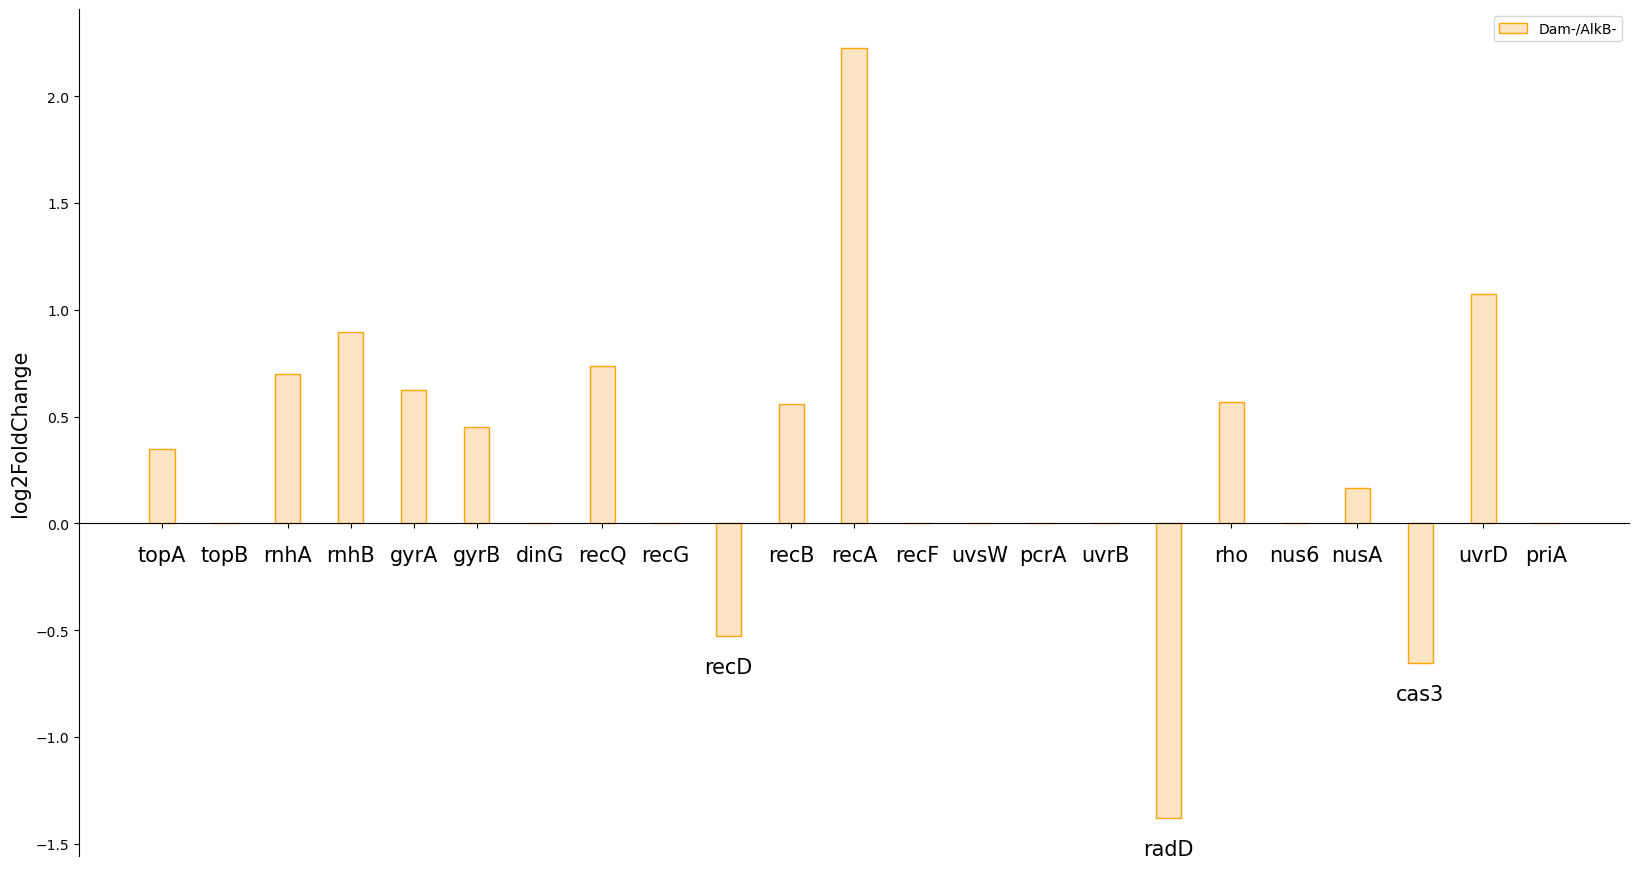

In [6]:
# Log2FoldChange Dam-/AlkB-
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.font_manager import FontProperties

# set width of bar 
barWidth = 0.4
fig, ax = plt.subplots(figsize = (20, 11)) 

# set height of bar 
Dam_min_Alkb_min = [0.348240, 0, 0.70122, 0.89443, 0.62590, 0.45337,
             0, 0.73829, 0, -0.52861, 0.55801, 2.22806, 0, 0, 0, 0,
             -1.37801, 0.56843, 0, 0.16594, -0.65306, 1.07613, 0]
# Set position of bar on X axis 
br1 = np.arange(len(Dam_min_Alkb_min)) 

# Make the plot
plt.bar(br1, Dam_min_Alkb_min, color ='bisque', width = barWidth, 
        edgecolor = 'orange', label ='Dam-/AlkB-')

plt.ylabel('log2FoldChange', fontsize = 15)

genes = ['topA', 'topB', 'rnhA', 'rnhB', 'gyrA', 'gyrB', 'dinG', 'recQ', 'recG',
         'recD', 'recB', 'recA', 'recF', 'uvsW', 'pcrA', 'uvrB', 'radD', 'rho',
         'nus6', 'nusA', 'cas3', 'uvrD', 'priA']

# Get the axes object
ax = plt.gca()
# remove the existing ticklabels
ax.set_xticklabels([])
# remove the extra tick on the negative bar
ax.set_xticks([idx for (idx, x) in enumerate(Dam_min_Alkb_min) if x > 0])
ax.spines["bottom"].set_position(("data", 0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# placing each of the x-axis labels individually
label_offset = 0.1
for gene, (x_position, y_position) in zip(genes, enumerate(Dam_min_Alkb_min)):
    if y_position > 0:
        label_y = -label_offset
    else:
        label_y = y_position - label_offset
    ax.text(x_position, label_y, gene, ha="center", va="top", fontsize = 15)

plt.legend()
plt.show()

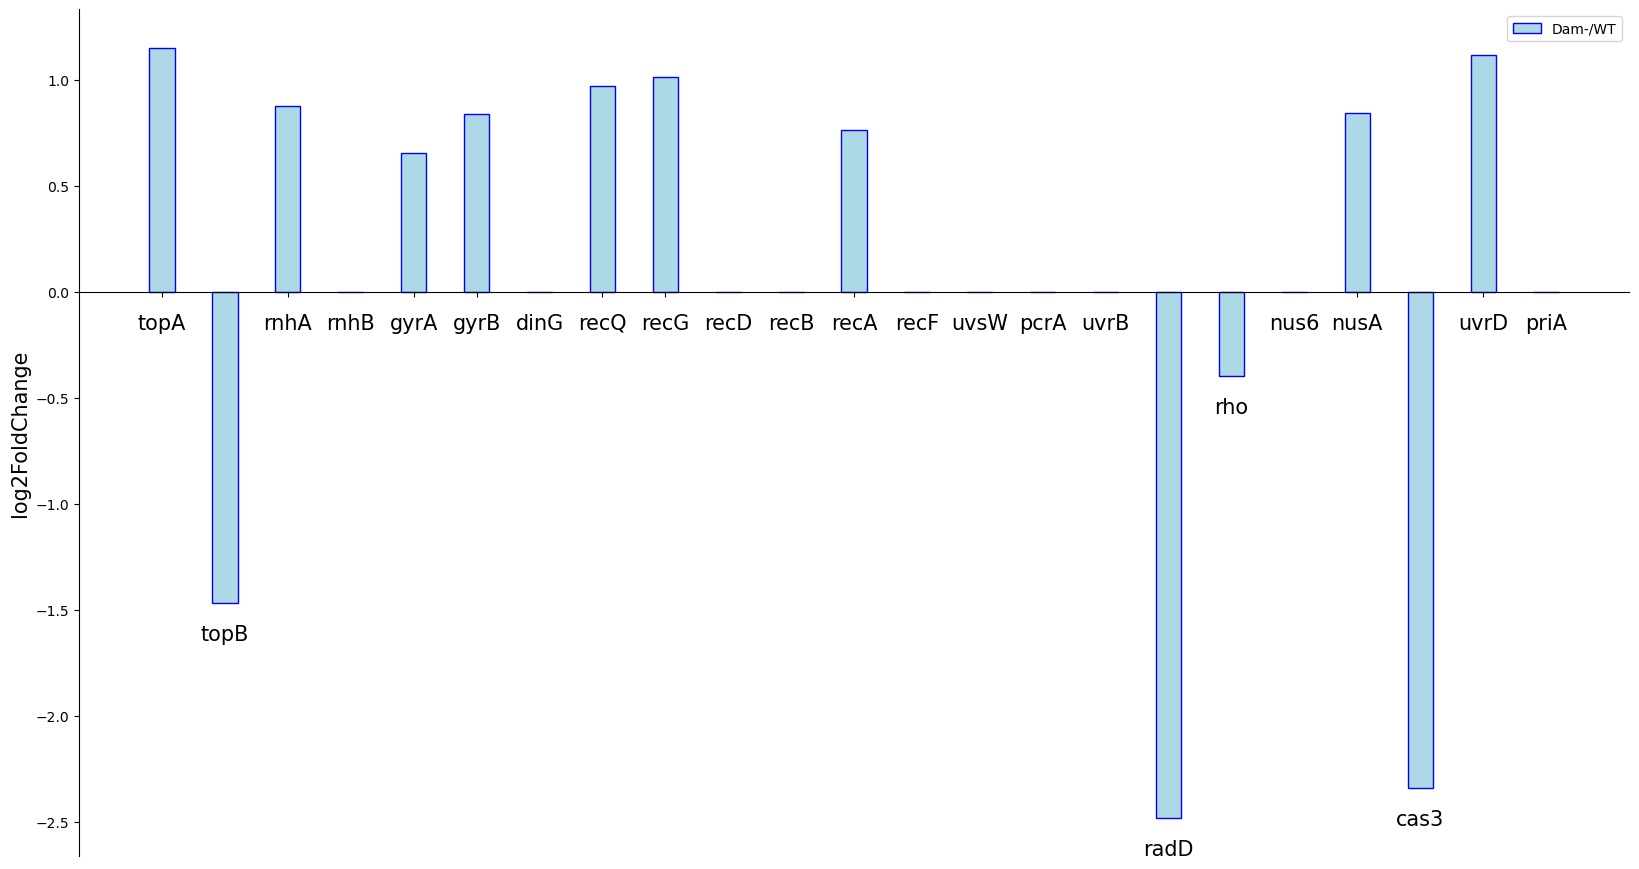

In [5]:
# Log2FoldChange Dam-/WT
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.font_manager import FontProperties

# set width of bar 
barWidth = 0.4
fig, ax = plt.subplots(figsize = (20, 11)) 

# set height of bar 
Dam_min_WT = [1.14966, -1.46878, 0.874777, 0, 0.653844, 0.83882,
             0, 0.969128, 1.01413, 0, 0, 0.762938, 0, 0, 0, 0,
             -2.48135, -0.398097, 0, 0.840458, -2.33932, 1.1139, 0]
# Set position of bar on X axis 
br1 = np.arange(len(Dam_min_WT)) 

# Make the plot
plt.bar(br1, Dam_min_WT, color ='lightblue', width = barWidth, 
        edgecolor = 'blue', label ='Dam-/WT')

plt.ylabel('log2FoldChange', fontsize = 15)

genes = ['topA', 'topB', 'rnhA', 'rnhB', 'gyrA', 'gyrB', 'dinG', 'recQ', 'recG',
         'recD', 'recB', 'recA', 'recF', 'uvsW', 'pcrA', 'uvrB', 'radD', 'rho',
         'nus6', 'nusA', 'cas3', 'uvrD', 'priA']

# Get the axes object
ax = plt.gca()
# remove the existing ticklabels
ax.set_xticklabels([])
# remove the extra tick on the negative bar
ax.set_xticks([idx for (idx, x) in enumerate(Dam_min_WT) if x > 0])
ax.spines["bottom"].set_position(("data", 0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# placing each of the x-axis labels individually
label_offset = 0.1
for gene, (x_position, y_position) in zip(genes, enumerate(Dam_min_WT)):
    if y_position > 0:
        label_y = -label_offset
    else:
        label_y = y_position - label_offset
    ax.text(x_position, label_y, gene, ha="center", va="top", fontsize = 15)

plt.legend()
plt.show()

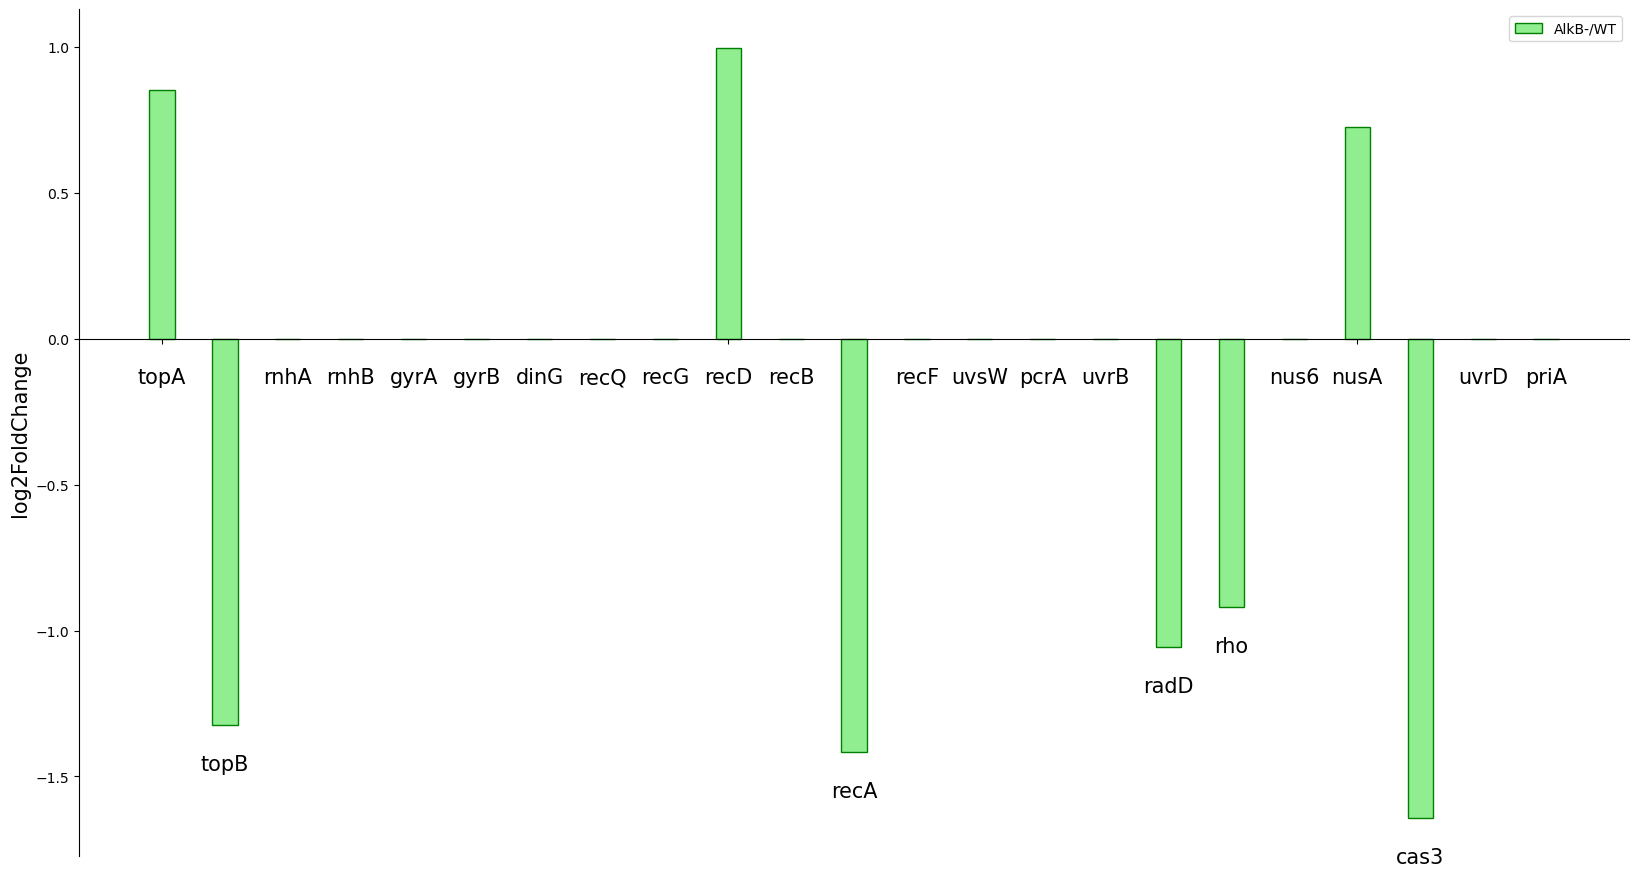

In [1]:
# Log2FoldChange AlkB-/WT
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.font_manager import FontProperties

# set width of bar 
barWidth = 0.4
fig, ax = plt.subplots(figsize = (20, 11)) 

# set height of bar 
AlkB_min_WT = [0.850634, -1.32266, 0, 0, 0, 0, 0, 0, 0, 0.996093, 0, -1.41758, 0, 0,
               0, 0, -1.0569, -0.91994, 0, 0.723413, -1.64155, 0, 0]

# Set position of bar on X axis 
br1 = np.arange(len(AlkB_min_WT)) 

# Make the plot
plt.bar(br1, AlkB_min_WT, color ='lightgreen', width = barWidth, 
        edgecolor = 'green', label ='AlkB-/WT')

plt.ylabel('log2FoldChange', fontsize = 15)

genes = ['topA', 'topB', 'rnhA', 'rnhB', 'gyrA', 'gyrB', 'dinG', 'recQ', 'recG',
         'recD', 'recB', 'recA', 'recF', 'uvsW', 'pcrA', 'uvrB', 'radD', 'rho',
         'nus6', 'nusA', 'cas3', 'uvrD', 'priA']

# Get the axes object
ax = plt.gca()
# remove the existing ticklabels
ax.set_xticklabels([])
# remove the extra tick on the negative bar
ax.set_xticks([idx for (idx, x) in enumerate(AlkB_min_WT) if x > 0])
ax.spines["bottom"].set_position(("data", 0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# placing each of the x-axis labels individually
label_offset = 0.1
for gene, (x_position, y_position) in zip(genes, enumerate(AlkB_min_WT)):
    if y_position > 0:
        label_y = -label_offset
    else:
        label_y = y_position - label_offset
    ax.text(x_position, label_y, gene, ha="center", va="top", fontsize = 15)

plt.legend()
plt.show()

**Comparison of WT DRIP-seq and RNA-seq data**

In [1]:
!cat ecoli_rnaseq_data/all_r.counts | head -n3

Geneid	Length	Alkb_Ecoli_1	Alkb_Ecoli_2	Alkb_Ecoli_3	DAM_Ecoli_1	DAM_Ecoli_2	DAM_Ecoli_3	WT_Ecoli_1	WT_Ecoli_2	WT_Ecoli_3
thrL	66	461	363	199	713	730	766	171	172	87
thrA	2463	382	366	216	560	663	604	80	79	61
cat: ошибка записи: Обрыв канала


In [4]:
!cat ecoli_rnaseq_data/all_bnums_r.counts | head -n3

Geneid	Length	Alkb_Ecoli_1	Alkb_Ecoli_2	Alkb_Ecoli_3	DAM_Ecoli_1	DAM_Ecoli_2	DAM_Ecoli_3	WT_Ecoli_1	WT_Ecoli_2	WT_Ecoli_3
b0001	66	461	363	199	713	730	766	171	172	87
b0002	2463	382	366	216	560	663	604	80	79	61
cat: ошибка записи: Обрыв канала


In [3]:
!wc -l ecoli_rnaseq_data/all_r.counts
# -1 = 4494 gene counts were found

4495 ecoli_rnaseq_data/all_r.counts


In [4]:
!wc -l ecoli_rnaseq_data/all_bnums_r.counts
# -1 = 4494 gene counts were found

4495 ecoli_rnaseq_data/all_bnums_r.counts


In [5]:
# Extract the needed columns (for RPKM calculation analysis of WT samples only)
!cut -f1,2,9-11 ecoli_rnaseq_data/all_r.counts > \
tmpfile; mv tmpfile ecoli_rnaseq_data/all_r_wt.counts

In [6]:
!cut -f1,2,9-11 ecoli_rnaseq_data/all_bnums_r.counts > \
tmpfile; mv tmpfile ecoli_rnaseq_data/all_bnums_r_wt.counts

In [7]:
!cat ecoli_rnaseq_data/all_r_wt.counts | head -n5

Geneid	Length	WT_Ecoli_1	WT_Ecoli_2	WT_Ecoli_3
thrL	66	171	172	87
thrA	2463	80	79	61
thrB	933	23	30	30
thrC	1287	48	45	46
cat: ошибка записи: Обрыв канала


In [8]:
!cat ecoli_rnaseq_data/all_bnums_r_wt.counts | head -n5

Geneid	Length	WT_Ecoli_1	WT_Ecoli_2	WT_Ecoli_3
b0001	66	171	172	87
b0002	2463	80	79	61
b0003	933	23	30	30
b0004	1287	48	45	46
cat: ошибка записи: Обрыв канала


Let's take the data with broad peaks of S9.6 WT (1) and overlappings of m6A/6mA and S9.6 WT (2):

In [2]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed

848 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed


In [3]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__wt_S96_intersections.bed

447 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__wt_S96_intersections.bed


In [21]:
# load WT RNA-seq expression dataset
import pandas as pd

df = pd.read_table("ecoli_rnaseq_data/all_r_wt.counts", sep="\s+")
df.head(2)

,Geneid,Length,WT_Ecoli_1,WT_Ecoli_2,WT_Ecoli_3
0,thrL,66,171,172,87
1,thrA,2463,80,79,61


In [22]:
# load WT RNA-seq expression dataset (b-nums)
df_bnums = pd.read_table("ecoli_rnaseq_data/all_bnums_r_wt.counts", sep="\s+")
df_bnums.head(2)

,Geneid,Length,WT_Ecoli_1,WT_Ecoli_2,WT_Ecoli_3
0,b0001,66,171,172,87
1,b0002,2463,80,79,61


In [23]:
# make gene column as index column
df = df.set_index('Geneid')
df.head(2)

,Length,WT_Ecoli_1,WT_Ecoli_2,WT_Ecoli_3
Geneid,,,,
thrL,66,171,172,87
thrA,2463,80,79,61


In [24]:
df_bnums = df_bnums.set_index('Geneid')
df_bnums.head(2)

,Length,WT_Ecoli_1,WT_Ecoli_2,WT_Ecoli_3
Geneid,,,,
b0001,66,171,172,87
b0002,2463,80,79,61


In [25]:
from bioinfokit.analys import norm, get_data

# now, normalize raw counts using RPKM method
# gene length must be in bp
nm = norm()
nm.rpkm(df=df, gl='Length')

# get RPKM normalized dataframe
rpkm_df = nm.rpkm_norm
rpkm_df.head(5)

# more inf: https://www.reneshbedre.com/blog/expression_units.html

,WT_Ecoli_1,WT_Ecoli_2,WT_Ecoli_3
Geneid,,,
thrL,256.586878,262.207493,144.321251
thrA,3.216680,3.227181,2.711567
thrB,2.441341,3.235193,3.520421
thrC,3.693558,3.517990,3.913220
yaaX,15.005081,16.599699,13.270920


In [26]:
# now, normalize raw counts using RPKM method (b-nums)
nm = norm()
nm.rpkm(df=df_bnums, gl='Length')

# get RPKM normalized dataframe
rpkm_df_bnums = nm.rpkm_norm
rpkm_df_bnums.head(5)

,WT_Ecoli_1,WT_Ecoli_2,WT_Ecoli_3
Geneid,,,
b0001,256.586878,262.207493,144.321251
b0002,3.216680,3.227181,2.711567
b0003,2.441341,3.235193,3.520421
b0004,3.693558,3.517990,3.913220
b0005,15.005081,16.599699,13.270920


In [27]:
rpkm_df['mean_rpkm'] = rpkm_df.mean(axis=1)
rpkm_df.head(5)

,WT_Ecoli_1,WT_Ecoli_2,WT_Ecoli_3,mean_rpkm
Geneid,,,,
thrL,256.586878,262.207493,144.321251,221.038541
thrA,3.216680,3.227181,2.711567,3.051809
thrB,2.441341,3.235193,3.520421,3.065652
thrC,3.693558,3.517990,3.913220,3.708256
yaaX,15.005081,16.599699,13.270920,14.958566


In [ ]:
////////

Then compare it with results from 'DRIP_peaks_differential_analysis.R':

In [24]:
import pandas as pd

volcano_wt_alkb = pd.read_csv('inf_gene_ids_WT_AlkB.csv', sep=' ', header=None)
volcano_wt_alkb.head()

,0
0,b2034
1,b2849
2,b4280
3,b4038
4,b4795


In [25]:
len(volcano_wt_alkb) # 627 rows

627

In [4]:
!cat ecoli_rnaseq_data/all_bnums_r.counts | head -n3

Geneid	Length	Alkb_Ecoli_1	Alkb_Ecoli_2	Alkb_Ecoli_3	DAM_Ecoli_1	DAM_Ecoli_2	DAM_Ecoli_3	WT_Ecoli_1	WT_Ecoli_2	WT_Ecoli_3
b0001	66	461	363	199	713	730	766	171	172	87
b0002	2463	382	366	216	560	663	604	80	79	61
cat: ошибка записи: Обрыв канала


In [19]:
!cut -f1-2,6-8 ecoli_rnaseq_data/all_bnums_r.counts > \
ecoli_rnaseq_data/all_bnums_r_wt_volcano.counts

In [20]:
!cat ecoli_rnaseq_data/all_bnums_r_wt_volcano.counts | head -n5

Geneid	Length	DAM_Ecoli_1	DAM_Ecoli_2	DAM_Ecoli_3
b0001	66	713	730	766
b0002	2463	560	663	604
b0003	933	368	401	386
b0004	1287	517	462	467
cat: ошибка записи: Обрыв канала


In [23]:
df_bnums_wt_volcano = pd.read_table("ecoli_rnaseq_data/all_bnums_r_wt_volcano.counts", sep="\s+")
df_bnums_wt_volcano.head(2)

,Geneid,Length,DAM_Ecoli_1,DAM_Ecoli_2,DAM_Ecoli_3
0,b0001,66,713,730,766
1,b0002,2463,560,663,604


In [24]:
df_bnums_wt_volcano = df_bnums_wt_volcano.set_index('Geneid')
df_bnums_wt_volcano.head(2)

,Length,DAM_Ecoli_1,DAM_Ecoli_2,DAM_Ecoli_3
Geneid,,,,
b0001,66,713,730,766
b0002,2463,560,663,604


In [25]:
# now, normalize raw counts using RPKM method (b-nums)
from bioinfokit.analys import norm, get_data
nm = norm()
nm.rpkm(df=df_bnums_wt_volcano, gl='Length')

# get RPKM normalized dataframe
rpkm_df_bnums_wt_volcano = nm.rpkm_norm
rpkm_df_bnums_wt_volcano.head(5)

,DAM_Ecoli_1,DAM_Ecoli_2,DAM_Ecoli_3
Geneid,,,
b0001,696.084592,737.729028,821.514290
b0002,14.650082,17.954242,17.358125
b0003,25.414560,28.666896,29.284374
b0004,25.883823,23.943155,25.684353
b0005,6.942405,7.635552,11.201384


In [26]:
rpkm_df_bnums_wt_volcano['mean_rpkm_wt'] = rpkm_df_bnums_wt_volcano.mean(axis=1)
rpkm_df_bnums_wt_volcano.head(5)

,DAM_Ecoli_1,DAM_Ecoli_2,DAM_Ecoli_3,mean_rpkm_wt
Geneid,,,,
b0001,696.084592,737.729028,821.514290,751.775970
b0002,14.650082,17.954242,17.358125,16.654149
b0003,25.414560,28.666896,29.284374,27.788610
b0004,25.883823,23.943155,25.684353,25.170444
b0005,6.942405,7.635552,11.201384,8.593114


In [27]:
d_bnums_wt_volcano = rpkm_df_bnums_wt_volcano['mean_rpkm_wt'].to_dict()

In [28]:
df_bnums_wt_volcano_rpkm = pd.DataFrame(d_bnums_wt_volcano.items(), columns=["Blattner number (b-number)", "RPKM value WT (mean)"])
df_bnums_wt_volcano_rpkm.head()

,Blattner number (b-number),RPKM value WT (mean)
0,b0001,751.775970
1,b0002,16.654149
2,b0003,27.788610
3,b0004,25.170444
4,b0005,8.593114


In [29]:
len(df_bnums_wt_volcano_rpkm['Blattner number (b-number)'])

4494

In [30]:
len(df_bnums_wt_volcano_rpkm['Blattner number (b-number)'].unique()) # nice. all are the unique

4494

In [14]:
!cut -f1-5 ecoli_rnaseq_data/all_bnums_r.counts > \
ecoli_rnaseq_data/all_bnums_r_alkb_volcano.counts

In [15]:
!cat ecoli_rnaseq_data/all_bnums_r_alkb_volcano.counts | head -n5

Geneid	Length	Alkb_Ecoli_1	Alkb_Ecoli_2	Alkb_Ecoli_3
b0001	66	461	363	199
b0002	2463	382	366	216
b0003	933	252	219	152
b0004	1287	322	245	195
cat: ошибка записи: Обрыв канала


In [16]:
df_bnums_alkb_volcano = pd.read_table("ecoli_rnaseq_data/all_bnums_r_alkb_volcano.counts", sep="\s+")
df_bnums_alkb_volcano.head(2)

,Geneid,Length,Alkb_Ecoli_1,Alkb_Ecoli_2,Alkb_Ecoli_3
0,b0001,66,461,363,199
1,b0002,2463,382,366,216


In [17]:
df_bnums_alkb_volcano = df_bnums_alkb_volcano.set_index('Geneid')
df_bnums_alkb_volcano.head(2)

,Length,Alkb_Ecoli_1,Alkb_Ecoli_2,Alkb_Ecoli_3
Geneid,,,,
b0001,66,461,363,199
b0002,2463,382,366,216


In [18]:
# now, normalize raw counts using RPKM method (b-nums)
from bioinfokit.analys import norm, get_data
nm = norm()
nm.rpkm(df=df_bnums_alkb_volcano, gl='Length')

# get RPKM normalized dataframe
rpkm_df_bnums_alkb_volcano = nm.rpkm_norm
rpkm_df_bnums_alkb_volcano.head(5)

,Alkb_Ecoli_1,Alkb_Ecoli_2,Alkb_Ecoli_3
Geneid,,,
b0001,433.458139,377.222121,304.515543
b0002,9.624743,10.191806,8.857062
b0003,16.761353,16.098927,16.453651
b0004,15.526283,13.056357,15.302289
b0005,15.670938,19.859873,14.962238


In [19]:
rpkm_df_bnums_alkb_volcano['mean_rpkm_alkb'] = rpkm_df_bnums_alkb_volcano.mean(axis=1)
rpkm_df_bnums_alkb_volcano.head(5)

,Alkb_Ecoli_1,Alkb_Ecoli_2,Alkb_Ecoli_3,mean_rpkm_alkb
Geneid,,,,
b0001,433.458139,377.222121,304.515543,371.731935
b0002,9.624743,10.191806,8.857062,9.557870
b0003,16.761353,16.098927,16.453651,16.437977
b0004,15.526283,13.056357,15.302289,14.628309
b0005,15.670938,19.859873,14.962238,16.831016


In [20]:
d_bnums_alkb_volcano = rpkm_df_bnums_alkb_volcano['mean_rpkm_alkb'].to_dict()

In [21]:
df_bnums_alkb_volcano_rpkm = pd.DataFrame(d_bnums_alkb_volcano.items(), columns=["Blattner number (b-number)", "RPKM value AlkB (mean)"])
df_bnums_alkb_volcano_rpkm.head()

,Blattner number (b-number),RPKM value AlkB (mean)
0,b0001,371.731935
1,b0002,9.557870
2,b0003,16.437977
3,b0004,14.628309
4,b0005,16.831016


In [22]:
len(df_bnums_alkb_volcano_rpkm['Blattner number (b-number)'])

4494

In [23]:
len(df_bnums_alkb_volcano_rpkm['Blattner number (b-number)'].unique()) # nice. all are the unique

4494

In [42]:
df_two_bnums_volcano_rpkm = pd.merge(df_bnums_wt_volcano_rpkm, df_bnums_alkb_volcano_rpkm, 
                                 on=['Blattner number (b-number)'], how='inner')
df_two_bnums_volcano_rpkm.head()

,Blattner number (b-number),RPKM value WT (mean),RPKM value AlkB (mean)
0,b0001,221.038541,371.731935
1,b0002,3.051809,9.557870
2,b0003,3.065652,16.437977
3,b0004,3.708256,14.628309
4,b0005,14.958566,16.831016


In [43]:
volcano_wt_alkb.head()

,0
0,b2034
1,b2849
2,b4280
3,b4038
4,b4795


In [44]:
volcano_wt_alkb.columns = ['Blattner number (b-number)']

In [45]:
volcano_wt_alkb.head()

,Blattner number (b-number)
0,b2034
1,b2849
2,b4280
3,b4038
4,b4795


In [46]:
len(volcano_wt_alkb)

627

In [47]:
df_two_bnums_volcano_rpkm_final = pd.merge(volcano_wt_alkb, df_two_bnums_volcano_rpkm, 
                                 on=['Blattner number (b-number)'], how='left')
df_two_bnums_volcano_rpkm_final.head()

,Blattner number (b-number),RPKM value WT (mean),RPKM value AlkB (mean)
0,b2034,3.148566,3.788179
1,b2849,0.164397,0.000000
2,b4280,2.970935,3.501506
3,b4038,NaN,NaN
4,b4795,0.000000,0.000000


In [48]:
len(df_two_bnums_volcano_rpkm_final)

627

In [50]:
# Create 'new_col' based on the condition
import numpy as np
df_two_bnums_volcano_rpkm_final['color'] = np.where(df_two_bnums_volcano_rpkm_final['RPKM value WT (mean)'] > df_two_bnums_volcano_rpkm_final['RPKM value AlkB (mean)'], 'red', 'green')

In [51]:
df_two_bnums_volcano_rpkm_final.head()

,Blattner number (b-number),RPKM value WT (mean),RPKM value AlkB (mean),color
0,b2034,3.148566,3.788179,green
1,b2849,0.164397,0.000000,red
2,b4280,2.970935,3.501506,green
3,b4038,NaN,NaN,green
4,b4795,0.000000,0.000000,green


In [52]:
df_two_bnums_volcano_rpkm_final.loc[df_two_bnums_volcano_rpkm_final['RPKM value WT (mean)'].isna(), 'color'] = 'black'

In [53]:
color_wt_alkb = df_two_bnums_volcano_rpkm_final['color'].tolist()

In [57]:
len(color_wt_alkb)

627

In [56]:
print(color_wt_alkb)

['green', 'red', 'green', 'black', 'green', 'red', 'green', 'red', 'red', 'green', 'green', 'green', 'green', 'black', 'black', 'green', 'green', 'black', 'red', 'red', 'green', 'green', 'black', 'green', 'green', 'red', 'green', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'green', 'green', 'red', 'green', 'red', 'green', 'green', 'green', 'green', 'red', 'red', 'green', 'green', 'red', 'red', 'green', 'red', 'green', 'green', 'black', 'green', 'green', 'green', 'green', 'green', 'red', 'green', 'black', 'red', 'red', 'red', 'green', 'green', 'black', 'green', 'red', 'green', 'black', 'red', 'green', 'black', 'green', 'green', 'green', 'red', 'red', 'green', 'green', 'green', 'red', 'black', 'red', 'red', 'red', 'red', 'red', 'green', 'green', 'green', 'red', 'red', 'red', 'green', 'red', 'green', 'green', 'red', 'green', 'black', 'green', 'green', 'red', 'green', 'green', 'green', 'red', 'green', 'green', 'green', 'green', 'red', 'green', 'red', 'green', 'green'

In [ ]:
# save it in file inf_color.txt

# tr -d "'" < inf_color.txt > inf_color_final.txt
# tr -d "," < inf_color_final.txt > inf_color_final_wt_alkb.txt

# then, this file should be implemented in the R script 'DRIP_peaks_differential_analysis.R'

In [3]:
volcano_wt_dam = pd.read_csv('inf_gene_ids_WT_Dam.csv', sep=' ', header=None)
volcano_wt_dam.head()

,0
0,b2269
1,b4462
2,b4128
3,b4495
4,b1038


In [5]:
!cat ecoli_rnaseq_data/all_bnums_r.counts | head -n3

Geneid	Length	Alkb_Ecoli_1	Alkb_Ecoli_2	Alkb_Ecoli_3	DAM_Ecoli_1	DAM_Ecoli_2	DAM_Ecoli_3	WT_Ecoli_1	WT_Ecoli_2	WT_Ecoli_3
b0001	66	461	363	199	713	730	766	171	172	87
b0002	2463	382	366	216	560	663	604	80	79	61
cat: ошибка записи: Обрыв канала


In [13]:
!cut -f1-2,6-8 ecoli_rnaseq_data/all_bnums_r.counts > \
ecoli_rnaseq_data/all_bnums_r_dam_volcano.counts

In [14]:
!cat ecoli_rnaseq_data/all_bnums_r_dam_volcano.counts | head -n5

Geneid	Length	DAM_Ecoli_1	DAM_Ecoli_2	DAM_Ecoli_3
b0001	66	713	730	766
b0002	2463	560	663	604
b0003	933	368	401	386
b0004	1287	517	462	467
cat: ошибка записи: Обрыв канала


In [13]:
df_bnums_dam_volcano = pd.read_table("ecoli_rnaseq_data/all_bnums_r_dam_volcano.counts", sep="\s+")
df_bnums_dam_volcano.head(2)

,Geneid,Length,DAM_Ecoli_1,DAM_Ecoli_2,DAM_Ecoli_3
0,b0001,66,713,730,766
1,b0002,2463,560,663,604


In [14]:
df_bnums_dam_volcano = df_bnums_dam_volcano.set_index('Geneid')
df_bnums_dam_volcano.head(2)

,Length,DAM_Ecoli_1,DAM_Ecoli_2,DAM_Ecoli_3
Geneid,,,,
b0001,66,713,730,766
b0002,2463,560,663,604


In [15]:
# now, normalize raw counts using RPKM method (b-nums)
from bioinfokit.analys import norm, get_data
nm = norm()
nm.rpkm(df=df_bnums_dam_volcano, gl='Length')

# get RPKM normalized dataframe
rpkm_df_bnums_dam_volcano = nm.rpkm_norm
rpkm_df_bnums_dam_volcano.head(5)

,DAM_Ecoli_1,DAM_Ecoli_2,DAM_Ecoli_3
Geneid,,,
b0001,696.084592,737.729028,821.514290
b0002,14.650082,17.954242,17.358125
b0003,25.414560,28.666896,29.284374
b0004,25.883823,23.943155,25.684353
b0005,6.942405,7.635552,11.201384


In [16]:
rpkm_df_bnums_dam_volcano['mean_rpkm_dam'] = rpkm_df_bnums_dam_volcano.mean(axis=1)
rpkm_df_bnums_dam_volcano.head(5)

,DAM_Ecoli_1,DAM_Ecoli_2,DAM_Ecoli_3,mean_rpkm_dam
Geneid,,,,
b0001,696.084592,737.729028,821.514290,751.775970
b0002,14.650082,17.954242,17.358125,16.654149
b0003,25.414560,28.666896,29.284374,27.788610
b0004,25.883823,23.943155,25.684353,25.170444
b0005,6.942405,7.635552,11.201384,8.593114


In [17]:
d_bnums_dam_volcano = rpkm_df_bnums_dam_volcano['mean_rpkm_dam'].to_dict()

In [18]:
df_bnums_dam_volcano_rpkm = pd.DataFrame(d_bnums_dam_volcano.items(), columns=["Blattner number (b-number)", "RPKM value DAM (mean)"])
df_bnums_dam_volcano_rpkm.head()

,Blattner number (b-number),RPKM value DAM (mean)
0,b0001,751.775970
1,b0002,16.654149
2,b0003,27.788610
3,b0004,25.170444
4,b0005,8.593114


In [19]:
len(df_bnums_dam_volcano_rpkm['Blattner number (b-number)'])

4494

In [20]:
len(df_bnums_dam_volcano_rpkm['Blattner number (b-number)'].unique()) # nice. all are the unique

4494

In [35]:
df_bnums_volcano_rpkm = pd.merge(df_bnums_wt_volcano_rpkm, df_bnums_dam_volcano_rpkm, 
                                 on=['Blattner number (b-number)'], how='inner')
df_bnums_volcano_rpkm.head()

,Blattner number (b-number),RPKM value WT (mean),RPKM value DAM (mean)
0,b0001,221.038541,751.775970
1,b0002,3.051809,16.654149
2,b0003,3.065652,27.788610
3,b0004,3.708256,25.170444
4,b0005,14.958566,8.593114


In [42]:
volcano_wt_dam.columns = ['Blattner number (b-number)']

In [43]:
volcano_wt_dam.head()

,Blattner number (b-number)
0,b2269
1,b4462
2,b4128
3,b4495
4,b1038


In [76]:
len(volcano_wt_dam)

492

In [74]:
df_bnums_volcano_rpkm_final = pd.merge(volcano_wt_dam, df_bnums_volcano_rpkm, 
                                 on=['Blattner number (b-number)'], how='left')
df_bnums_volcano_rpkm_final.head()

,Blattner number (b-number),RPKM value WT (mean),RPKM value DAM (mean)
0,b2269,0.763176,2.002040
1,b4462,NaN,NaN
2,b4128,3.097322,3.451746
3,b4495,NaN,NaN
4,b1038,1.149290,5.062665


In [75]:
len(df_bnums_volcano_rpkm_final)

492

In [77]:
# Create 'new_col' based on the condition
import numpy as np
df_bnums_volcano_rpkm_final['color'] = np.where(df_bnums_volcano_rpkm_final['RPKM value WT (mean)'] > df_bnums_volcano_rpkm_final['RPKM value DAM (mean)'], 'red', 'blue')

In [78]:
df_bnums_volcano_rpkm_final.head()

,Blattner number (b-number),RPKM value WT (mean),RPKM value DAM (mean),color
0,b2269,0.763176,2.002040,blue
1,b4462,NaN,NaN,blue
2,b4128,3.097322,3.451746,blue
3,b4495,NaN,NaN,blue
4,b1038,1.149290,5.062665,blue


In [81]:
df_bnums_volcano_rpkm_final.loc[df_bnums_volcano_rpkm_final['RPKM value WT (mean)'].isna(), 'color'] = 'black'

In [82]:
color_wt_dam = df_bnums_volcano_rpkm_final['color'].tolist()

In [83]:
len(color_wt_dam)

492

In [84]:
print(color_wt_dam)

['blue', 'black', 'blue', 'black', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'black', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'black', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'black', 'blue', 'blue', 'blue', 'black', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'black', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'black', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'black', 'r

In [ ]:
# save it in file inf_color.txt

# tr -d "'" < inf_color.txt > inf_color_final.txt
# tr -d "," < inf_color_final.txt > inf_color_final_wt_dam.txt

# then, this file should be implemented in the R script 'DRIP_peaks_differential_analysis.R'

**Boxplots formation**

In [21]:
import pandas as pd

# compare df with DRIP-seq results (WT R-loops subset)
drip_wt_df = pd.read_csv('extracted_gene_namess_unique.txt', sep=' ', header=None)
drip_wt_df.head()

,0
0,abgT
1,abrB
2,aceK-int
3,acnA
4,acnB


In [5]:
# also df with DIP and DRIP-seq overlapping results (WT R-loops and m6A/6mA subset)
dip_drip_wt_df = pd.read_csv('extracted_gene_namess_unique_m6A.txt', sep=' ', header=None)
dip_drip_wt_df.head()

,0
0,acs
1,adeQ
2,agaR
3,agaS
4,agp


In [22]:
drip_wt_df.columns = ['Gene name']
drip_wt_df.head()

,Gene name
0,abgT
1,abrB
2,aceK-int
3,acnA
4,acnB


In [9]:
dip_drip_wt_df.columns = ['Gene name']
dip_drip_wt_df.head()

,Gene name
0,acs
1,adeQ
2,agaR
3,agaS
4,agp


In [10]:
len(drip_wt_df.axes[0]) # 789 results out of 848 peaks S9.6 WT

789

In [12]:
len(dip_drip_wt_df.axes[0]) # 401 results (genes) out of 447 peaks m6A/6mA and
# S9.6 WT

401

In [13]:
len(drip_wt_df['Gene name'].unique()) # ok

789

In [19]:
len(dip_drip_wt_df['Gene name'].unique()) # ok

401

In [37]:
df_wt_rpkm['Gene name'].isin(drip_wt_df['Gene name']).value_counts()

Gene name
False    3705
True      789
Name: count, dtype: int64

In [39]:
df_wt_rpkm['Gene name'].isin(dip_drip_wt_df['Gene name']).value_counts()

Gene name
False    4093
True      401
Name: count, dtype: int64

In [40]:
rna_drip_intersections_df = pd.merge(df_wt_rpkm, drip_wt_df, on=['Gene name'], how='inner')
rna_drip_intersections_df.head()

# Genes that contain R-loops

,Gene name,RPKM value
0,thrL,221.038541
1,yaaJ,6.521702
2,nhaA,73.045422
3,insA1,0.000000
4,carA,14.302539


In [43]:
dip_drip_intersections_df = pd.merge(df_wt_rpkm, dip_drip_wt_df, on=['Gene name'], how='inner')
dip_drip_intersections_df.head()

# Genes that contain both R-loops and m6A/6mA

,Gene name,RPKM value
0,carA,14.302539
1,caiF,11.644635
2,caiD,0.214427
3,caiT,0.458574
4,leuO,6.636534


In [44]:
len(rna_drip_intersections_df.axes[0]) # 789 results - ok

789

In [46]:
len(dip_drip_intersections_df.axes[0]) # 401 results - ok

401

In [47]:
condition = df_wt_rpkm['Gene name'].isin(rna_drip_intersections_df['Gene name'])

In [48]:
df_wt_rpkm_non_r_loops = df_wt_rpkm.drop(df_wt_rpkm[condition].index)

In [49]:
df_wt_rpkm_non_r_loops.head()

# Genes that do not contain R-loops

,Gene name,RPKM value
1,thrA,3.051809
2,thrB,3.065652
3,thrC,3.708256
4,yaaX,14.958566
5,yaaA,1.668779


In [50]:
len(df_wt_rpkm_non_r_loops.axes[0]) # 3705 results - ok

3705

In [51]:
rna_drip_intersections_df['subtype'] = 'R-loops containing'

In [52]:
dip_drip_intersections_df['subtype'] = 'm6A/6mA and R-loops containing'

In [53]:
rna_drip_intersections_df = rna_drip_intersections_df.rename(columns={'Gene name': 'sample', 
                                                                      'RPKM value': 'rpkm'})

In [55]:
dip_drip_intersections_df = dip_drip_intersections_df.rename(columns={'Gene name': 'sample', 
                                                                      'RPKM value': 'rpkm'})

In [56]:
rna_drip_intersections_df = rna_drip_intersections_df[['sample', 'subtype', 'rpkm']]

In [58]:
dip_drip_intersections_df = dip_drip_intersections_df[['sample', 'subtype', 'rpkm']]

In [59]:
rna_drip_intersections_df.head()

,sample,subtype,rpkm
0,thrL,R-loops containing,221.038541
1,yaaJ,R-loops containing,6.521702
2,nhaA,R-loops containing,73.045422
3,insA1,R-loops containing,0.000000
4,carA,R-loops containing,14.302539


In [61]:
dip_drip_intersections_df.head()

,sample,subtype,rpkm
0,carA,m6A/6mA and R-loops containing,14.302539
1,caiF,m6A/6mA and R-loops containing,11.644635
2,caiD,m6A/6mA and R-loops containing,0.214427
3,caiT,m6A/6mA and R-loops containing,0.458574
4,leuO,m6A/6mA and R-loops containing,6.636534


In [49]:
df_wt_rpkm_non_r_loops['subtype'] = 'Non R-loops containing'

In [50]:
df_wt_rpkm_non_r_loops = df_wt_rpkm_non_r_loops.rename(columns={'Gene name': 'sample', 
                                                                'RPKM value': 'rpkm'})

In [51]:
df_wt_rpkm_non_r_loops = df_wt_rpkm_non_r_loops[['sample', 'subtype', 'rpkm']]

In [52]:
df_wt_rpkm_non_r_loops.head()

,sample,subtype,rpkm
1,thrA,Non R-loops containing,3.051809
2,thrB,Non R-loops containing,3.065652
3,thrC,Non R-loops containing,3.708256
4,yaaX,Non R-loops containing,14.958566
5,yaaA,Non R-loops containing,1.668779


In [53]:
data_wt = pd.concat([rna_drip_intersections_df,
                     df_wt_rpkm_non_r_loops, dip_drip_intersections_df],
                      ignore_index = True,
                      sort = False)

In [54]:
data_wt.head()

,sample,subtype,rpkm
0,thrL,R-loops containing,221.038541
1,yaaJ,R-loops containing,6.521702
2,nhaA,R-loops containing,73.045422
3,insA1,R-loops containing,0.000000
4,carA,R-loops containing,14.302539


In [55]:
len(data_wt.axes[0]) # 4895 = 4494 + 401 results - ok

4895

In [57]:
data_wt.to_csv('boxplot_data_wt.csv')